# Phase 8 — Advanced Privacy-Preserving Continual Learning Methods

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## Overview and design rationale

This notebook implements three advanced continual learning techniques and evaluates
them in direct comparison to the CDML baseline from Phase 3.
Each method addresses a different weakness of plain CDML.

---

### Method A — Wavelet Generative Replay + CDML (WGR-CDML)

**Problem it solves:** CDML eliminates catastrophic forgetting at zero replay cost,
but its forgetting mitigation relies entirely on the orthogonality of the binary
sequences. In a *dataset-incremental* scenario (different acquisition devices or
sessions per task), the distribution shift between tasks is large enough that
sequence orthogonality alone may be insufficient.

**Idea:** Generate lightweight synthetic proxy samples from each completed task
using the *Redundant Discrete Wavelet Transform* (RDWT) applied to a small
set of retained summary statistics — specifically the **per-class, per-channel
low-frequency approximation coefficients** (cA) and a compressed representation
of the **high-frequency detail coefficients** (cD). No raw biometric windows
are stored; only the frequency-domain statistics are retained.

At replay time, surrogate windows are reconstructed via the inverse DWT from
these statistics, injected with label-preserving jitter, and passed through CDML
with the appropriate task seed before training. This is *privacy-preserving* because:
- Raw sensor windows are never stored
- Reconstruction is stochastic (jitter) so exact inversion of real samples is impossible
- The CDML scrambling layer prevents MIA on the synthetic samples too

**Connection to literature:** This approach operationalises the *R-Tuning* idea
(Wavelet-guided Replay) adapted to 1-D IMU signals. The DWT decomposes the
128-sample gait window into multi-resolution subbands, capturing both the
low-frequency locomotion cycle and the high-frequency foot-contact transients.

---

### Method B — CaSpeR: Continual Spectral Regularisation

**Paper:** Frascaroli et al., *"Latent Spectral Regularization for Continual Learning"*,
Pattern Recognition Letters, 2024 (arXiv:2301.03345)

**Problem it solves:** When a small replay buffer is used alongside CDML,
the buffer data from different classes increasingly *mix together* in the
latent space — a phenomenon documented by Frascaroli et al. This makes the
downstream linear classifier's task harder and increases forgetting.

**How it works:** CaSpeR builds a *Latent Geometry Graph* (LGG) over the
buffer embeddings: nodes are embeddings, edges connect the k nearest neighbours
of each node. The normalised graph Laplacian L = I − D^{-1/2} A D^{-1/2}
has eigenvalues λ₁ ≤ λ₂ ≤ ... ≤ λ_N. The number of eigenvalues near zero
equals the number of loosely-connected graph components — i.e., the number
of well-separated clusters. CaSpeR's loss penalises insufficient separation:

```
L_CaSpeR = -( λ_{g+1} - λ_g ) + Σ_{i=1}^{g} λ_i
```

where g = number of distinct classes in the current buffer. Minimising this
encourages a large eigengap at position g (g well-separated clusters) while
keeping the first g eigenvalues small (tight intra-class clusters).

**Adaptation for our system:** We apply CaSpeR on top of 10% experience replay
+ CDML, using the scrambled embedding m = s_k ⊙ h rather than the raw h.
This tests whether spectral regularisation is compatible with CDML's scrambled
feature space.

---

### Method C — LiDER: Lipschitz-Driven Experience Replay

**Paper:** Bonicelli et al., *"On the Effectiveness of Lipschitz-Driven Rehearsal
in Continual Learning"*, NeurIPS 2022 (arXiv:2210.06443)

**Problem it solves:** Repeated optimisation on a small fixed buffer
causes *buffer overfitting* — the model memorises the exact buffer samples,
leading to tight and brittle decision boundaries that generalise poorly.

**How it works:** LiDER adds a surrogate Lipschitz constraint on each
network layer. For each layer l, it computes the spectral norm
σ(W_l) ≈ ‖W_l‖₂ (the largest singular value of the weight matrix),
which upper-bounds the layer's Lipschitz constant. A regularisation
penalty then penalises layers where the Lipschitz constant w.r.t.
the replay examples exceeds a target value:

```
L_LiDER = Σ_l max(0, σ(W_l) - κ)²
```

where κ is a target spectral norm (hyperparameter). This smooths the model's
output surface over the replay buffer neighbourhood, reducing overfitting.

**Adaptation:** We apply LiDER to the Conv and Linear layers of GaitCNN
during all tasks (k ≥ 2) while using CDML's binary modulation.

---

## Applicability assessment for gait IMU data

| Method | Applicable? | Notes |
|---|---|---|
| **WGR-CDML** | ✓ Fully applicable | 1-D DWT is native to time-series; approximation coefficients compress the 128-pt window efficiently |
| **CaSpeR** | ✓ Fully applicable | Works on any latent space; small buffer (10%) is the recommended use case |
| **LiDER** | ✓ Fully applicable | Compatible with any network; spectral norm computed per Conv1d/Linear layer |

All three require a small replay buffer (10% in this notebook), which
is consistent with the paper's ablation (CDML + 10% replay).


## 0. Imports and device

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc
from sklearn.manifold import TSNE
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

# PyWavelets for DWT-based synthetic replay
try:
    import pywt
    PYWT_AVAILABLE = True
    print(f'PyWavelets {pywt.__version__} found')
except ImportError:
    PYWT_AVAILABLE = False
    print('PyWavelets not found — will use numpy FFT-based approximation instead')
    print('Install with: pip install PyWavelets')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

PyWavelets 1.6.0 found
Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [48]:
TRAIN_DATA_DIR  = '../Data/Dataset_1/train'
TEST_DATA_DIR   = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

EPOCHS   = 50    # 400 = paper accurate; 50 = fast iteration
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── Method-specific hyperparameters ──────────────────────────────────────────
REPLAY_FRAC      = 0.10   # 10% replay buffer for B, C (matches paper ablation)

# Method A — Wavelet Generative Replay
WGR_WAVELET      = 'db4'   # Daubechies-4 — good for IMU transients
WGR_LEVEL        = 3       # decomposition levels (128 → level-3 approx = 16 pts)
WGR_N_SYNTH      = 30      # synthetic windows generated per real buffer sample
WGR_JITTER_STD   = 0.05    # std of additive Gaussian jitter on reconstructed signal

# Method B — CaSpeR
CASPER_WEIGHT    = 0.10    # λ in  L_total = L_CE + λ * L_CaSpeR
CASPER_KNN       = 5       # k for the Latent Geometry Graph

# Method C — LiDER
LIDER_WEIGHT     = 0.01    # λ in  L_total = L_CE + λ * L_LiDER
LIDER_KAPPA      = 2.0     # target spectral norm κ per layer

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading — identical to all previous phases

In [49]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    return np.stack(signals, axis=1).astype(np.float32), \
           np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std( axis=(0, 2), keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx,
                       X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val],
                                         generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test
Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model definitions — identical backbone as Phase 3

In [50]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    """Baseline CNN — Zou et al. 2020 / Milani 2024 (Fig. 2 gray blocks)."""
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(
            torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(self.embed(x))


def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    raw = rng.random(embed_dim)
    return torch.tensor(
        np.where(raw >= 0.5, 1.0, -1.0).astype(np.float32))


class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer(
            'sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h):
        return h * self.sequence


class GaitCNN_CDML(nn.Module):
    """GaitCNN + CDML layer — baseline from Phase 3."""
    def __init__(self, n_channels=6, n_classes=118,
                 embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds: dict = {}

    def embed_raw(self, x):
        """Raw backbone embedding h (before CDML)."""
        return self.backbone.embed(x)

    def embed_modulated(self, x):
        """Scrambled embedding m = s_k ⊙ h."""
        return self.cdml(self.backbone.embed(x))

    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))

    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total


def make_replay_buffer(train_ds, frac, seed=RANDOM_SEED):
    """Return a TensorDataset of `frac` fraction of train_ds."""
    n   = len(train_ds)
    k   = max(1, int(n * frac))
    idx = torch.randperm(n, generator=torch.Generator().manual_seed(seed))[:k]
    Xs  = torch.stack([train_ds[i][0] for i in idx.tolist()])
    ys  = torch.stack([train_ds[i][1] for i in idx.tolist()])
    return TensorDataset(Xs, ys)


print(f'GaitCNN params: '
      f'{sum(p.numel() for p in GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).parameters()):,}')

GaitCNN params: 227,222


## 4. MIA utilities — LiRA (reused from Phase 4)

In [51]:
@torch.no_grad()
def get_logit_scores(model, dataset, device, cdml_task=None, batch_size=256):
    """LiRA score: logit of the correct-class softmax probability."""
    model.eval()
    if cdml_task and hasattr(model, 'seeds') and cdml_task in model.seeds:
        model.set_task_sequence(cdml_task, model.seeds[cdml_task])
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    scores = []
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        probs = torch.softmax(model(X_b), dim=1)
        p_c   = probs[torch.arange(len(y_b)), y_b].clamp(1e-7, 1 - 1e-7)
        scores.append(torch.log(p_c / (1 - p_c)).cpu().numpy())
    return np.concatenate(scores)


def compute_mia_auc_eer(member_s, nonmember_s):
    labels = np.concatenate([np.ones(len(member_s)), np.zeros(len(nonmember_s))])
    scores = np.concatenate([member_s, nonmember_s])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc     = auc(fpr, tpr)
    fnr = 1 - tpr
    eer = float(np.mean([fpr[np.nanargmin(np.abs(fpr - fnr))],
                          fnr[np.nanargmin(np.abs(fpr - fnr))]]))
    return roc_auc * 100, eer * 100, fpr, tpr


def full_mia_table(model, task_data, task_names, device, label=''):
    """Run LiRA on all tasks and return (auc_mat, eer_mat)."""
    n       = len(task_names)
    auc_mat = np.full((n, n), np.nan)
    eer_mat = np.full((n, n), np.nan)
    for j, t in enumerate(task_names):
        m_s  = get_logit_scores(model, task_data[t]['train'], device, cdml_task=t)
        nm_s = get_logit_scores(model, task_data[t]['test'],  device, cdml_task=t)
        a, e, _, _ = compute_mia_auc_eer(m_s, nm_s)
        auc_mat[:, j] = a   # same value for all rows (final model)
        eer_mat[:, j] = e
    if label:
        print(f'  {label} — mean AUC={np.nanmean(auc_mat[:,]):.1f}%  '
              f'mean EER={np.nanmean(eer_mat[:,]):.1f}%')
    return auc_mat, eer_mat


print('MIA utilities defined.')

MIA utilities defined.


---
## Method A — Wavelet Generative Replay + CDML (WGR-CDML)

### Wavelet decomposition background

The Discrete Wavelet Transform (DWT) decomposes a 1-D signal of length T into:
- **Approximation coefficients cA** at level L: low-frequency content (locomotion cycle, ~0–4 Hz)
- **Detail coefficients cD₁,...,cD_L**: high-frequency content at successive scales
  (foot contact transients, sensor noise)

For a 128-sample window with Daubechies-4 at level 3:
- cA3 has ~16 coefficients (captures the ~0–4 Hz gait cycle)
- cD3, cD2, cD1 have ~16, 32, 64 coefficients respectively

### Privacy-preserving replay protocol

After training on task k, instead of storing raw windows, we store:
1. **Per-class mean cA3** (approximation statistics): captures the average
   low-frequency gait pattern for each enrolled subject
2. **Per-class covariance of cA3**: captures intra-subject variation
3. **Global detail statistics** (mean ± std of each cD level across all subjects
   in the task): captures the characteristic high-frequency texture of the task
   without storing individual identity information

At replay time, synthetic windows are generated by:
1. Sampling cA3 from N(μ_class, Σ_class)
2. Sampling detail coefficients from the global task-level statistics
3. Reconstructing via inverse DWT
4. Adding small Gaussian jitter to prevent exact repetition

In [52]:
# ── Wavelet utilities ─────────────────────────────────────────────────────────

def dwt_decompose(X_np, wavelet=WGR_WAVELET, level=WGR_LEVEL):
    """
    Decompose a batch of windows via DWT.
    X_np : (N, C, T) numpy float32
    Returns coeffs_list where each element is a (N, C, coeff_len) array:
      [cA_level, cD_level, cD_level-1, ..., cD_1]
    """
    if PYWT_AVAILABLE:
        N, C, T = X_np.shape
        # Decompose one channel at a time to collect all coefficients
        all_coeffs = []
        for n in range(N):
            sample_coeffs = []  # per level
            for c in range(C):
                coeffs = pywt.wavedec(X_np[n, c, :], wavelet, level=level)
                # coeffs = [cA, cD_L, cD_{L-1}, ..., cD_1]
                sample_coeffs.append(coeffs)
            all_coeffs.append(sample_coeffs)
        return all_coeffs  # [N][C][level+1]
    else:
        # Fallback: low-pass / high-pass via FFT
        return _fft_approximate(X_np)


def _fft_approximate(X_np, low_frac=0.125):
    """
    FFT-based fallback when PyWavelets is not available.
    Splits spectrum at `low_frac` of Nyquist.
    Returns (X_low, X_high) as (N, C, T) arrays.
    """
    F   = np.fft.rfft(X_np, axis=-1)
    cut = max(1, int(F.shape[-1] * low_frac))
    F_l = F.copy(); F_l[..., cut:] = 0
    F_h = F.copy(); F_h[..., :cut] = 0
    return np.fft.irfft(F_l, n=X_np.shape[-1], axis=-1), \
           np.fft.irfft(F_h, n=X_np.shape[-1], axis=-1)


class WaveletReplayBuffer:
    """
    Privacy-preserving replay buffer based on DWT statistics.

    Stores per-task summary statistics (never raw windows):
      - Per-class mean and covariance of level-L approximation coefficients
      - Global task mean/std of each detail level

    Generates synthetic windows on demand via inverse DWT + jitter.
    """

    def __init__(self, wavelet=WGR_WAVELET, level=WGR_LEVEL,
                 n_synth=WGR_N_SYNTH, jitter_std=WGR_JITTER_STD,
                 seed=RANDOM_SEED):
        self.wavelet   = wavelet
        self.level     = level
        self.n_synth   = n_synth
        self.jitter    = jitter_std
        self.rng       = np.random.default_rng(seed)
        self._tasks: list[dict] = []   # per-task statistics

    def _extract_raw(self, train_ds):
        """Materialise training dataset into (X_np, y_np) arrays."""
        X = torch.stack([train_ds[i][0] for i in range(len(train_ds))]).numpy()
        y = torch.stack([train_ds[i][1] for i in range(len(train_ds))]).numpy()
        return X, y

    def add_task(self, train_ds, task_name):
        """
        Compress task training data into wavelet statistics and store.
        No raw windows are retained.
        """
        X_np, y_np = self._extract_raw(train_ds)
        N, C, T    = X_np.shape
        classes    = np.unique(y_np)

        if PYWT_AVAILABLE:
            all_coeffs = dwt_decompose(X_np, self.wavelet, self.level)

            # Per-class approximation statistics (level = 0 → cA)
            class_stats = {}
            for cls in classes:
                mask = (y_np == cls)
                # Stack cA vectors for this class: shape (n_cls, C, len_cA)
                cA_stack = np.array(
                    [[all_coeffs[i][c][0] for c in range(C)]
                     for i in range(N) if mask[i]])   # (n_cls, C, len_cA)
                flat = cA_stack.reshape(cA_stack.shape[0], -1)  # (n_cls, C*len_cA)
                class_stats[int(cls)] = {
                    'mu':    flat.mean(axis=0),
                    'sigma': flat.std(axis=0) + 1e-6,
                }

            # Global detail statistics (across all samples in task)
            detail_stats = []
            for lv in range(1, self.level + 1):  # cD levels
                cD_all = np.array(
                    [[all_coeffs[i][c][lv] for c in range(C)]
                     for i in range(N)])   # (N, C, len_cD)
                detail_stats.append({
                    'mu':    cD_all.mean(axis=0),
                    'sigma': cD_all.std(axis=0) + 1e-6,
                })

            # Store the wavelet structure of a reference sample (for shape info)
            ref_coeffs = all_coeffs[0][0]   # one sample, channel 0
            coeff_lens  = [len(c) for c in ref_coeffs]

        else:
            # FFT-based fallback
            X_low, X_high = _fft_approximate(X_np)
            class_stats = {}
            for cls in classes:
                mask = (y_np == cls)
                flat = X_low[mask].reshape(mask.sum(), -1)
                class_stats[int(cls)] = {
                    'mu': flat.mean(axis=0), 'sigma': flat.std(axis=0) + 1e-6}
            detail_stats = [{'mu': X_high.mean(axis=0),
                              'sigma': X_high.std(axis=0) + 1e-6}]
            coeff_lens = None

        self._tasks.append({
            'task_name':    task_name,
            'class_stats':  class_stats,
            'detail_stats': detail_stats,
            'coeff_lens':   coeff_lens,
            'n_channels':   C,
            'window_size':  T,
            'classes':      list(classes.astype(int)),
        })

        total_stats = sum(v['mu'].size + v['sigma'].size
                          for v in class_stats.values())
        print(f'  WGR buffer: stored statistics for {task_name} — '
              f'{len(classes)} classes, {total_stats} floats '
              f'(no raw windows retained)')

    def synthesize_task(self, task_idx):
        """
        Generate n_synth synthetic windows per class for a past task.
        Returns a TensorDataset of (X_synth, y_synth).
        """
        task = self._tasks[task_idx]
        C, T = task['n_channels'], task['window_size']
        X_list, y_list = [], []

        if PYWT_AVAILABLE:
            for cls, stats in task['class_stats'].items():
                mu, sigma = stats['mu'], stats['sigma']
                for _ in range(self.n_synth):
                    # Sample approximation coefficients
                    cA_flat = self.rng.normal(mu, sigma)  # (C * len_cA,)
                    cA      = cA_flat.reshape(C, -1)      # (C, len_cA)

                    # Sample detail coefficients from global task statistics
                    window = np.zeros((C, T), dtype=np.float32)
                    for c in range(C):
                        # Build coefficient list for this channel
                        coeffs_c = [cA[c].astype(float)]
                        for lv_stats in task['detail_stats']:
                            mu_d = lv_stats['mu'][c]
                            sg_d = lv_stats['sigma'][c]
                            cD   = self.rng.normal(mu_d, sg_d).astype(float)
                            coeffs_c.append(cD)

                        # Inverse DWT to reconstruct signal
                        recon = pywt.waverec(coeffs_c, self.wavelet)
                        # Trim or pad to window size
                        if len(recon) >= T:
                            window[c] = recon[:T].astype(np.float32)
                        else:
                            window[c, :len(recon)] = recon.astype(np.float32)

                    # Add small jitter
                    window += self.rng.normal(0, self.jitter,
                                              size=window.shape).astype(np.float32)
                    X_list.append(window)
                    y_list.append(cls)

        else:
            # FFT fallback: sample from class low-freq statistics + global high-freq
            for cls, stats in task['class_stats'].items():
                mu, sigma = stats['mu'], stats['sigma']
                for _ in range(self.n_synth):
                    x_low  = self.rng.normal(mu, sigma).reshape(C, T // 4)
                    x_low  = np.repeat(x_low, 4, axis=-1)[:, :T]
                    det    = task['detail_stats'][0]
                    x_high = self.rng.normal(det['mu'], det['sigma'])
                    if x_high.shape[-1] != T:
                        x_high = x_high.reshape(C, -1)
                        x_high = np.pad(x_high, ((0,0),(0,max(0,T-x_high.shape[-1]))))
                        x_high = x_high[:, :T]
                    window = (x_low + x_high).astype(np.float32)
                    window += self.rng.normal(0, self.jitter,
                                              size=window.shape).astype(np.float32)
                    X_list.append(window)
                    y_list.append(cls)

        X_t = torch.tensor(np.stack(X_list))
        y_t = torch.tensor(y_list, dtype=torch.long)
        return TensorDataset(X_t, y_t)

    def get_replay_dataset(self):
        """Generate synthetic datasets for ALL stored past tasks and concatenate."""
        if not self._tasks:
            return None
        all_ds = [self.synthesize_task(i) for i in range(len(self._tasks))]
        return ConcatDataset(all_ds)


print('WaveletReplayBuffer defined.')

WaveletReplayBuffer defined.


  WGR buffer: stored statistics for Task 1 — 30 classes, 7920 floats (no raw windows retained)


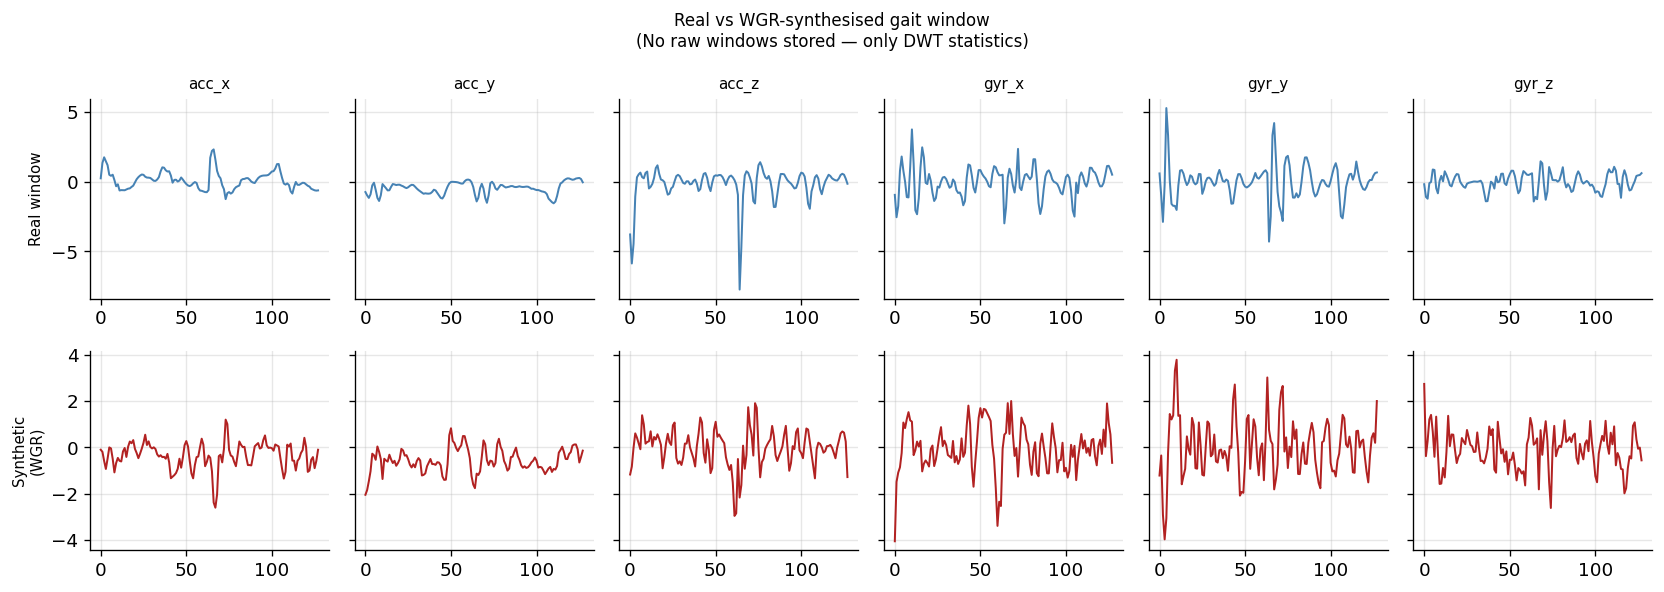

In [53]:
# ── Visualise wavelet reconstruction quality ──────────────────────────────────
# Demonstrate that synthetic samples look like realistic gait windows

sample_task = 'Task 1'
buf_demo    = WaveletReplayBuffer(n_synth=5)
buf_demo.add_task(task_data[sample_task]['train'], sample_task)
synth_ds    = buf_demo.synthesize_task(0)

# Pick one real and one synthetic sample from the same class
real_X, real_y = next(iter(DataLoader(task_data[sample_task]['train'],
                                       batch_size=1, shuffle=True)))
synth_X, synth_y = synth_ds[0]

fig, axes = plt.subplots(2, N_CHANNELS, figsize=(14, 5), sharey='row')
ch_names = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
for c in range(N_CHANNELS):
    axes[0, c].plot(real_X[0, c].numpy(), color='steelblue', lw=1.2)
    axes[0, c].set_title(ch_names[c], fontsize=9)
    if c == 0:
        axes[0, c].set_ylabel('Real window', fontsize=9)

    axes[1, c].plot(synth_X[c].numpy(), color='firebrick', lw=1.2)
    if c == 0:
        axes[1, c].set_ylabel('Synthetic\n(WGR)', fontsize=9)

plt.suptitle('Real vs WGR-synthesised gait window\n'
             '(No raw windows stored — only DWT statistics)', fontsize=10)
plt.tight_layout()
plt.savefig('../Plots/fig_phase8_wgr_sample.png', bbox_inches='tight')
plt.show()

In [54]:
def run_wgr_cdml(task_data, task_names, device,
                  epochs, lr_init, lr_decay, batch_size,
                  n_synth=WGR_N_SYNTH, verbose_every=20):
    """
    WGR-CDML: at each step k, replay is provided by the wavelet generative
    buffer (no raw data stored). The CDML sequence is applied per-task
    so that synthetic samples from past tasks are modulated with their
    correct key before training.

    Training data at step k:
      current_task_real  + wavelet_synthetic_from_tasks_{1..k-1}
    All data passes through the model's current-task CDML sequence.
    """
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()
    wgr_buffer = WaveletReplayBuffer(n_synth=n_synth)

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[WGR-CDML] Step {step_idx+1}: {task_name}')
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)

        # Build training data: real current task + synthetic past tasks
        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth_replay = wgr_buffer.get_replay_dataset()
            if synth_replay is not None:
                datasets.append(synth_replay)
                print(f'  + {len(synth_replay)} synthetic samples from past tasks')
        combined = ConcatDataset(datasets)
        loader   = DataLoader(combined, batch_size=batch_size, shuffle=True)

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        for epoch in range(1, epochs + 1):
            model.train()
            model.set_task_sequence(task_name, seed_k)   # ensure correct sequence
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                criterion(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()

            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        # Evaluate on all seen tasks
        for ei, et in enumerate(task_names[:step_idx + 1]):
            model.set_task_sequence(et, model.seeds[et])
            tl = DataLoader(task_data[et]['test'], batch_size=batch_size)
            acc = evaluate(model, tl, device)
            acc_matrix[step_idx, ei] = acc
            print(f'  {et}: {acc*100:.1f}%')

        # Add current task to wavelet buffer (no raw data stored)
        wgr_buffer.add_task(task_data[task_name]['train'], task_name)

    return model, acc_matrix


print('\n' + '='*55)
print('Method A: WGR-CDML')
print('='*55)
torch.manual_seed(RANDOM_SEED)
model_wgr, acc_wgr = run_wgr_cdml(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)


Method A: WGR-CDML

[WGR-CDML] Step 1: Task 1
  Epoch   1/50  val=0.941
  Epoch  20/50  val=0.991
  Epoch  40/50  val=0.990
  Task 1: 89.7%
  WGR buffer: stored statistics for Task 1 — 30 classes, 7920 floats (no raw windows retained)

[WGR-CDML] Step 2: Task 2
  + 900 synthetic samples from past tasks
  Epoch   1/50  val=0.933
  Epoch  20/50  val=0.975
  Epoch  40/50  val=0.988
  Task 1: 87.3%
  Task 2: 94.4%
  WGR buffer: stored statistics for Task 2 — 30 classes, 7920 floats (no raw windows retained)

[WGR-CDML] Step 3: Task 3
  + 1800 synthetic samples from past tasks
  Epoch   1/50  val=0.954
  Epoch  20/50  val=0.984
  Epoch  40/50  val=0.984
  Task 1: 81.4%
  Task 2: 86.4%
  Task 3: 91.8%
  WGR buffer: stored statistics for Task 3 — 30 classes, 7920 floats (no raw windows retained)

[WGR-CDML] Step 4: Task 4
  + 2700 synthetic samples from past tasks
  Epoch   1/50  val=0.967
  Epoch  20/50  val=0.985
  Epoch  40/50  val=0.985
  Task 1: 51.4%
  Task 2: 62.9%
  Task 3: 84.4%
  T

---
## Method B — CaSpeR: Continual Spectral Regularisation

### Mathematical formulation

Given a batch of buffer embeddings H = {h₁,...,h_N}, build the
*Latent Geometry Graph* (LGG) G = (V, E) where:
- Nodes V = {h₁,...,h_N}
- Edges E connect k-nearest neighbours by cosine similarity

The **adjacency matrix** A[i,j] = cosine_similarity(hᵢ, hⱼ) if j ∈ kNN(i), else 0.

The **normalised Laplacian** L = I − D^{-½} A D^{-½},
where D is the diagonal degree matrix.

The Laplacian eigenvalues λ₁ ≤ ... ≤ λ_N indicate cluster structure:
the number of eigenvalues near 0 equals the number of graph partitions.

**CaSpeR loss** (Frascaroli et al. 2024, Eq. 5):
```
L_CaSpeR = -(λ_{g+1} - λ_g) + Σ_{i=1}^{g} λ_i
```
where g = number of distinct classes in the buffer.

Minimising this:
- Maximises λ_{g+1} − λ_g (the eigengap → encourages g well-separated clusters)
- Minimises Σ λ_i (keeps intra-class embeddings compact)

### Efficient batch computation

For N up to BATCH_SIZE, forming the full N×N Laplacian is feasible.
For larger batches, we sub-sample at most N_MAX_CASPER nodes.
Eigenvalues are computed with `torch.linalg.eigvalsh` (symmetric matrix).

In [55]:
DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: cpu  |  PyTorch: 2.8.0


In [56]:
N_MAX_CASPER = 128   # maximum LGG size for efficient eigenvalue computation

def casper_loss(embeddings, labels, k=CASPER_KNN, n_max=N_MAX_CASPER):
    """
    CaSpeR spectral regularisation loss.
    (Frascaroli et al., Pattern Recognition Letters 2024)

    Parameters
    ----------
    embeddings : (N, D) — batch of latent vectors (can be h or m = s_k ⊙ h)
    labels     : (N,)   — class labels
    k          : int    — k-NN for LGG construction
    n_max      : int    — max nodes to keep (sub-sampled if N > n_max)

    Returns
    -------
    Scalar loss value.
    """
    N = embeddings.shape[0]

    # Sub-sample if batch too large
    if N > n_max:
        idx = torch.randperm(N, device=embeddings.device)[:n_max]
        embeddings = embeddings[idx]
        labels     = labels[idx]
        N          = n_max

    g = int(labels.unique().shape[0])   # number of distinct classes in batch
    if g < 2 or N < g + 1:
        return torch.tensor(0.0, device=embeddings.device)

    # ── Build adjacency matrix via cosine similarity ──────────────────────
    h_norm = F.normalize(embeddings, dim=1)         # (N, D)
    sim    = h_norm @ h_norm.t()                    # (N, N) cosine similarities

    # Keep only k-NN edges (zero out all but top-k per row)
    top_k_vals, top_k_idx = sim.topk(k=min(k + 1, N), dim=1)
    A = torch.zeros_like(sim)
    A.scatter_(1, top_k_idx, top_k_vals)
    A = (A + A.t()) / 2          # symmetrise
    A.fill_diagonal_(0)          # no self-loops
    A = A.clamp(min=0)           # ensure non-negative weights

    # ── Normalised Laplacian L = I − D^{-½} A D^{-½} ─────────────────────
    deg    = A.sum(dim=1).clamp(min=1e-8)           # (N,)
    d_inv  = deg.pow(-0.5)
    D_inv  = torch.diag(d_inv)                      # (N, N)
    L      = torch.eye(N, device=A.device) - D_inv @ A @ D_inv

    # ── Eigenvalues (ascending) ───────────────────────────────────────────
    # eigvalsh is numerically stable for symmetric matrices
    lambdas = torch.linalg.eigvalsh(L)              # (N,) sorted ascending

    # ── CaSpeR loss: maximise eigengap at g, minimise sum of first g ─────
    # Eq. 5 from Frascaroli et al. 2024:
    #   L = -(lambda_{g+1} - lambda_g) + sum_{i=0}^{g-1} lambda_i
    eigengap   = lambdas[g] - lambdas[g - 1]        # λ_{g+1} - λ_g (0-indexed)
    sum_first  = lambdas[:g].sum()                   # Σ λ_i for i=1..g
    loss       = -eigengap + sum_first

    return loss


def run_casper_cdml(task_data, task_names, device,
                     epochs, lr_init, lr_decay, batch_size,
                     replay_frac=REPLAY_FRAC,
                     casper_weight=CASPER_WEIGHT,
                     knn=CASPER_KNN,
                     verbose_every=20):
    """
    CaSpeR-CDML: experience replay (10%) + CDML + CaSpeR regularisation.

    The CaSpeR loss is applied on the CDML-modulated embeddings m = s_k ⊙ h
    using the buffer data at each training step. This tests whether
    spectral regularisation is compatible with CDML's scrambled feature space.
    """
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()
    replay_buf : list[TensorDataset] = []   # raw replay buffer (small)

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[CaSpeR-CDML] Step {step_idx+1}: {task_name}')
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)

        # Training DataLoader: current task + replay
        datasets = [task_data[task_name]['train']]
        if replay_buf:
            datasets += replay_buf
        combined_ds = ConcatDataset(datasets)
        loader      = DataLoader(combined_ds, batch_size=batch_size, shuffle=True)

        # Separate buffer-only loader for CaSpeR (needs ALL past classes together)
        buf_loader = None
        if replay_buf:
            all_buf = ConcatDataset(replay_buf)
            buf_loader = DataLoader(all_buf, batch_size=min(N_MAX_CASPER,
                                                            len(all_buf)),
                                     shuffle=True)

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        for epoch in range(1, epochs + 1):
            model.train()
            model.set_task_sequence(task_name, seed_k)

            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()

                # Standard classification loss
                loss = criterion(model(X_b), y_b)

                # CaSpeR regularisation on buffer embeddings
                if buf_loader is not None:
                    X_buf, y_buf = next(iter(buf_loader))
                    X_buf, y_buf = X_buf.to(device), y_buf.to(device)
                    # Use scrambled embeddings m = s_k ⊙ h
                    m_buf  = model.embed_modulated(X_buf)
                    c_loss = casper_loss(m_buf, y_buf, k=knn)
                    loss   = loss + casper_weight * c_loss

                loss.backward()
                optimizer.step()

            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        for ei, et in enumerate(task_names[:step_idx + 1]):
            model.set_task_sequence(et, model.seeds[et])
            tl  = DataLoader(task_data[et]['test'], batch_size=batch_size)
            acc = evaluate(model, tl, device)
            acc_matrix[step_idx, ei] = acc
            print(f'  {et}: {acc*100:.1f}%')

        # Add current task to replay buffer
        replay_buf.append(make_replay_buffer(
            task_data[task_name]['train'], replay_frac))
        print(f'  Buffer total: {sum(len(d) for d in replay_buf)} samples')

    return model, acc_matrix


print('\n' + '='*55)
print('Method B: CaSpeR-CDML')
print('='*55)
torch.manual_seed(RANDOM_SEED)
model_casper, acc_casper = run_casper_cdml(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)


Method B: CaSpeR-CDML

[CaSpeR-CDML] Step 1: Task 1
  Epoch   1/50  val=0.939
  Epoch  20/50  val=0.992
  Epoch  40/50  val=0.992
  Task 1: 89.6%
  Buffer total: 734 samples

[CaSpeR-CDML] Step 2: Task 2
  Epoch   1/50  val=0.947
  Epoch  20/50  val=0.982
  Epoch  40/50  val=0.978
  Task 1: 88.1%
  Task 2: 94.2%
  Buffer total: 1458 samples

[CaSpeR-CDML] Step 3: Task 3
  Epoch   1/50  val=0.964
  Epoch  20/50  val=0.979
  Epoch  40/50  val=0.977
  Task 1: 63.4%
  Task 2: 68.4%
  Task 3: 91.0%
  Buffer total: 2112 samples

[CaSpeR-CDML] Step 4: Task 4
  Epoch   1/50  val=0.951
  Epoch  20/50  val=0.987
  Epoch  40/50  val=0.984
  Task 1: 42.3%
  Task 2: 51.4%
  Task 3: 47.2%
  Task 4: 96.8%
  Buffer total: 2813 samples


---
## Method C — LiDER: Lipschitz-Driven Experience Replay

### Mathematical formulation

For each layer l with weight matrix W_l, the spectral norm
σ(W_l) = ‖W_l‖₂ (largest singular value) is an upper bound on the
Lipschitz constant of that layer.

**LiDER penalty** (Bonicelli et al., NeurIPS 2022):
```
L_LiDER = Σ_l  max(0, σ(W_l) − κ)²
```

This is a soft constraint that penalises any layer whose spectral norm
exceeds target κ. Minimising this makes the model's output smoother
around the replay buffer, reducing overfitting to the small buffer.

### Efficient spectral norm approximation

Computing the exact SVD at every step is expensive. We use
**power iteration** (1–3 steps) to approximate the leading singular value.
For 1-D convolutional layers, we reshape the weight tensor to 2-D
(out_channels × in_channels × kernel_size → out_channels × rest)
before applying power iteration.

In [57]:
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: mps  |  PyTorch: 2.8.0


In [58]:
def spectral_norm_approx(W, n_iter=3):
    """
    Approximate the spectral norm (largest singular value) of weight W
    using power iteration. Works for any 2-D+ weight tensor.
    """
    # Reshape to 2-D: (rows, cols)
    W2d = W.view(W.shape[0], -1)   # (out, in * k)
    if W2d.shape[1] == 0 or W2d.shape[0] == 0:
        return torch.tensor(0.0, device=W.device)

    # Random initialisation of right singular vector
    u = F.normalize(torch.randn(W2d.shape[0], 1,
                                 device=W.device), dim=0)
    v = F.normalize(torch.randn(W2d.shape[1], 1,
                                 device=W.device), dim=0)

    for _ in range(n_iter):
        v = F.normalize(W2d.t() @ u, dim=0)
        u = F.normalize(W2d @ v,     dim=0)

    sigma = (u.t() @ W2d @ v).squeeze()
    return sigma.abs()


def lider_loss(model, kappa=LIDER_KAPPA):
    """
    LiDER Lipschitz penalty.
    (Bonicelli et al., NeurIPS 2022)

    Penalises any layer whose spectral norm exceeds the target κ:
        L_LiDER = Σ_l max(0, σ(W_l) − κ)²

    Applied to all Conv1d and Linear layers in the backbone.
    """
    total = torch.tensor(0.0, device=next(model.parameters()).device)
    backbone = model.backbone if hasattr(model, 'backbone') else model

    for module in backbone.modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            W     = module.weight
            sigma = spectral_norm_approx(W)
            excess = F.relu(sigma - kappa)
            total  = total + excess ** 2

    return total


def run_lider_cdml(task_data, task_names, device,
                    epochs, lr_init, lr_decay, batch_size,
                    replay_frac=REPLAY_FRAC,
                    lider_weight=LIDER_WEIGHT,
                    kappa=LIDER_KAPPA,
                    verbose_every=20):
    """
    LiDER-CDML: experience replay (10%) + CDML + Lipschitz regularisation.

    LiDER is added from step 2 onwards (needs replay buffer to be non-empty).
    """
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()
    replay_buf : list[TensorDataset] = []

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[LiDER-CDML] Step {step_idx+1}: {task_name}')
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)

        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets),
                              batch_size=batch_size, shuffle=True)

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        for epoch in range(1, epochs + 1):
            model.train()
            model.set_task_sequence(task_name, seed_k)

            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()

                loss = criterion(model(X_b), y_b)

                # LiDER penalty (from task 2 onwards)
                if step_idx > 0:
                    loss = loss + lider_weight * lider_loss(model, kappa=kappa)

                loss.backward()
                optimizer.step()

            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        for ei, et in enumerate(task_names[:step_idx + 1]):
            model.set_task_sequence(et, model.seeds[et])
            tl  = DataLoader(task_data[et]['test'], batch_size=batch_size)
            acc = evaluate(model, tl, device)
            acc_matrix[step_idx, ei] = acc
            print(f'  {et}: {acc*100:.1f}%')

        replay_buf.append(make_replay_buffer(
            task_data[task_name]['train'], replay_frac))

    return model, acc_matrix


print('\n' + '='*55)
print('Method C: LiDER-CDML')
print('='*55)
torch.manual_seed(RANDOM_SEED)
model_lider, acc_lider = run_lider_cdml(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)


Method C: LiDER-CDML

[LiDER-CDML] Step 1: Task 1
  Epoch   1/50  val=0.941
  Epoch  20/50  val=0.991
  Epoch  40/50  val=0.990
  Task 1: 89.7%

[LiDER-CDML] Step 2: Task 2
  Epoch   1/50  val=0.948
  Epoch  20/50  val=0.979
  Epoch  40/50  val=0.987
  Task 1: 90.5%
  Task 2: 93.2%

[LiDER-CDML] Step 3: Task 3
  Epoch   1/50  val=0.959
  Epoch  20/50  val=0.980
  Epoch  40/50  val=0.979
  Task 1: 81.2%
  Task 2: 87.7%
  Task 3: 91.8%

[LiDER-CDML] Step 4: Task 4
  Epoch   1/50  val=0.928
  Epoch  20/50  val=0.981
  Epoch  40/50  val=0.985
  Task 1: 44.1%
  Task 2: 70.1%
  Task 3: 87.0%
  Task 4: 98.3%


---
## Baseline: CDML (no replay) — re-run for fair comparison

In [59]:
def run_cdml_baseline(task_data, task_names, device,
                       epochs, lr_init, lr_decay, batch_size,
                       verbose_every=20):
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        print(f'\n[CDML] Step {step_idx+1}: {task_name}')
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                criterion(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'],
                                batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  '
                      f'val={evaluate(model, vl, device):.3f}')

        for ei, et in enumerate(task_names[:step_idx + 1]):
            model.set_task_sequence(et, model.seeds[et])
            tl  = DataLoader(task_data[et]['test'], batch_size=batch_size)
            acc = evaluate(model, tl, device)
            acc_matrix[step_idx, ei] = acc
            print(f'  {et}: {acc*100:.1f}%')

    return model, acc_matrix


print('\n' + '='*55)
print('Baseline: CDML (no replay)')
print('='*55)
torch.manual_seed(RANDOM_SEED)
model_cdml, acc_cdml = run_cdml_baseline(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)


Baseline: CDML (no replay)

[CDML] Step 1: Task 1
  Epoch   1/50  val=0.941
  Epoch  20/50  val=0.991
  Epoch  40/50  val=0.990
  Task 1: 89.7%

[CDML] Step 2: Task 2
  Epoch   1/50  val=0.956
  Epoch  20/50  val=0.987
  Epoch  40/50  val=0.989
  Task 1: 79.1%
  Task 2: 93.9%

[CDML] Step 3: Task 3
  Epoch   1/50  val=0.953
  Epoch  20/50  val=0.979
  Epoch  40/50  val=0.984
  Task 1: 54.6%
  Task 2: 72.9%
  Task 3: 93.0%

[CDML] Step 4: Task 4
  Epoch   1/50  val=0.965
  Epoch  20/50  val=0.986
  Epoch  40/50  val=0.989
  Task 1: 43.9%
  Task 2: 68.3%
  Task 3: 75.1%
  Task 4: 98.3%


---
## 5. Accuracy comparison — forgetting curves and matrices

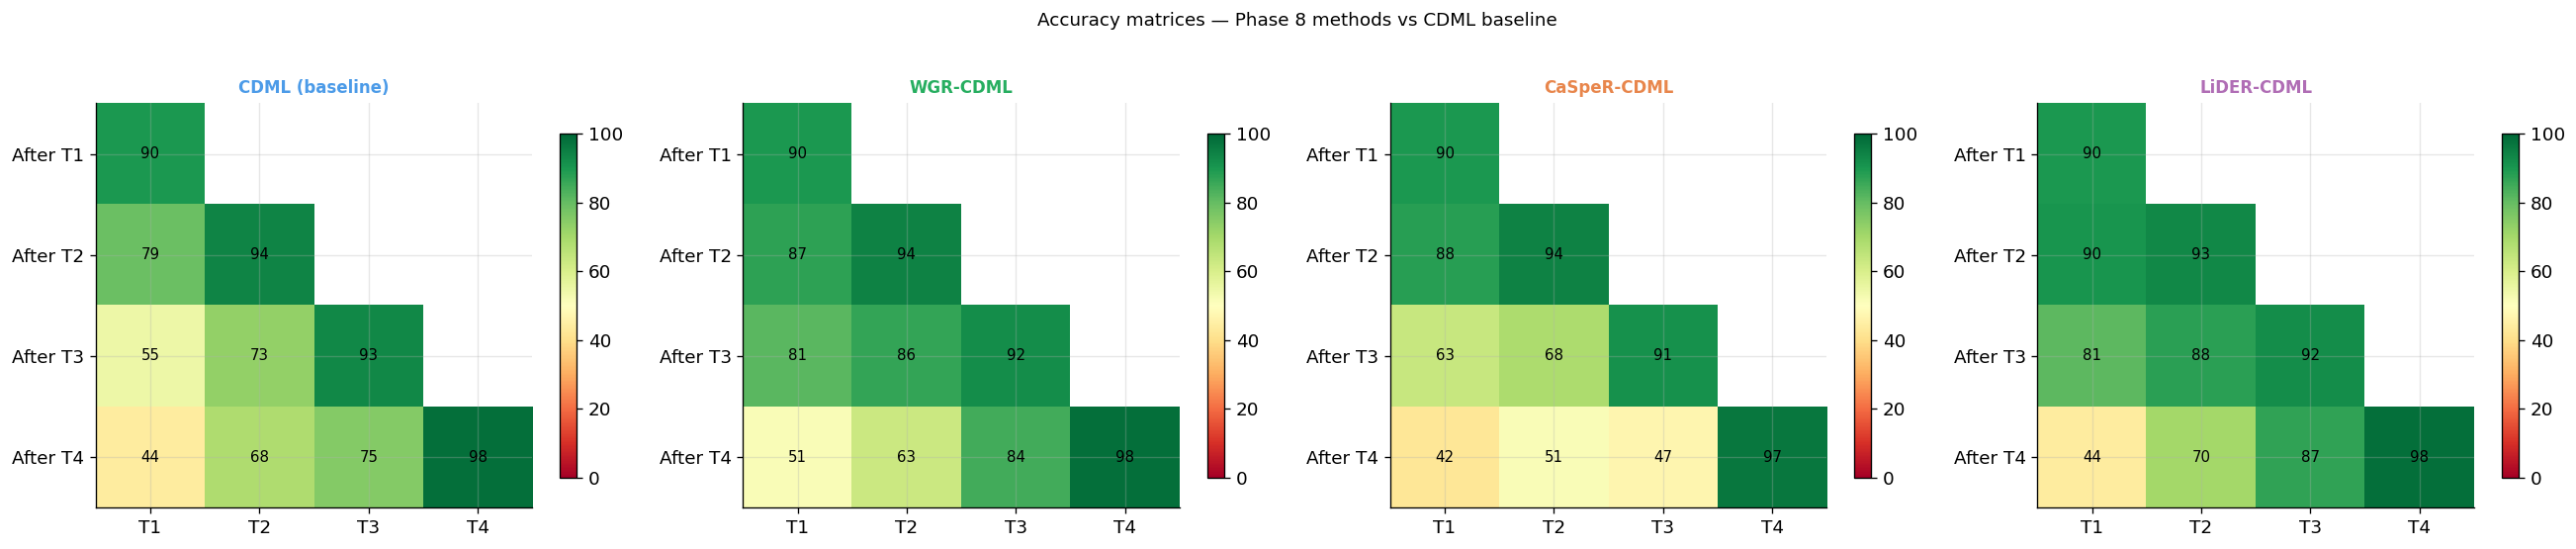

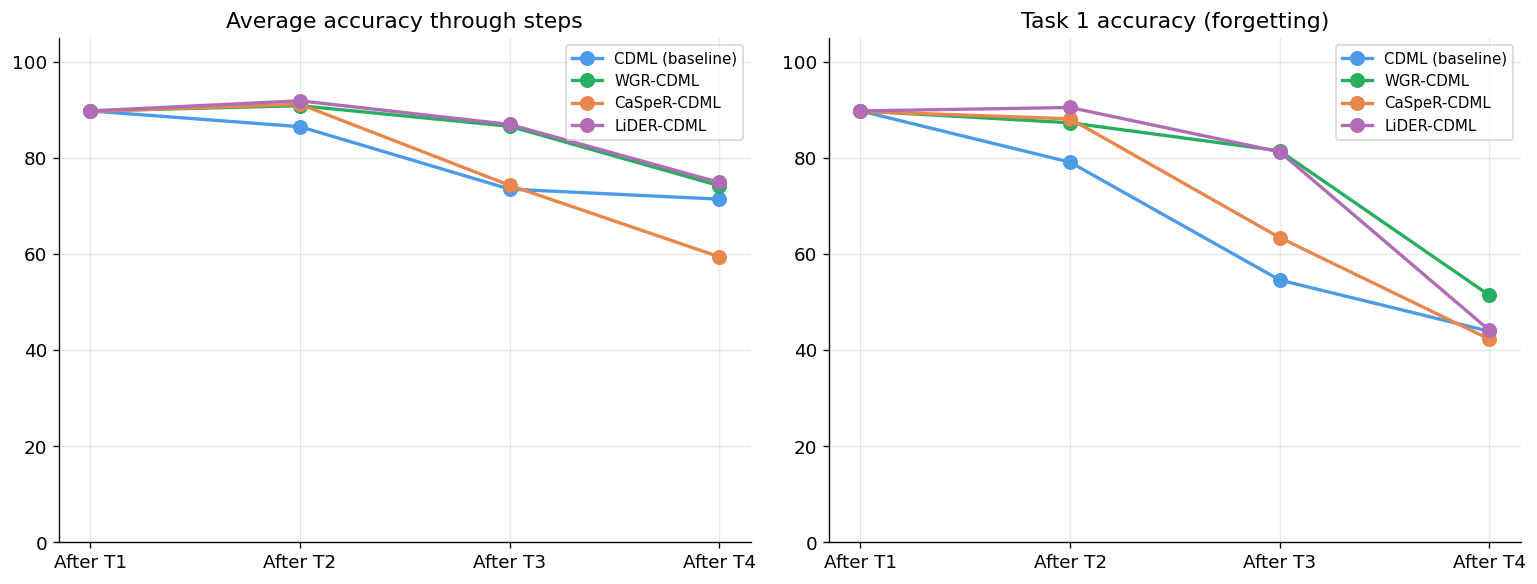

── Forgetting summary (Task 1: initial → final) ──
  CDML (baseline)     : T1 89.7%→43.9% (Δ=45.8 pp)  avg_final=71.4%
  WGR-CDML            : T1 89.7%→51.4% (Δ=38.4 pp)  avg_final=74.2%
  CaSpeR-CDML         : T1 89.6%→42.3% (Δ=47.4 pp)  avg_final=59.4%
  LiDER-CDML          : T1 89.7%→44.1% (Δ=45.6 pp)  avg_final=74.9%


In [60]:
all_runs = [
    ('CDML (baseline)',  acc_cdml,   '#4C9BE8', model_cdml),
    ('WGR-CDML',        acc_wgr,    '#27AE60', model_wgr),
    ('CaSpeR-CDML',     acc_casper, '#E8864C', model_casper),
    ('LiDER-CDML',      acc_lider,  '#B06DB5', model_lider),
]

# ── Accuracy matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(all_runs), figsize=(5.5 * len(all_runs), 4.5))
for ax, (label, mat, color, _) in zip(axes, all_runs):
    masked = np.ma.masked_invalid(mat * 100)
    im     = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.85)
    ax.set_xticks(range(n_tasks)); ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)])
    ax.set_yticklabels([f'After T{i+1}' for i in range(n_tasks)])
    ax.set_title(label, fontsize=10, fontweight='bold', color=color)
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(mat[i, j]):
                v = mat[i, j] * 100
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=9, color='black' if v > 25 else 'white')

fig.suptitle('Accuracy matrices — Phase 8 methods vs CDML baseline',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../Plots/fig_phase8_accuracy_matrices.png', bbox_inches='tight')
plt.show()

# ── Average accuracy and Task 1 forgetting ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, mat, color, _ in all_runs:
    avg   = [np.nanmean(mat[s, :s+1]) * 100 for s in range(n_tasks)]
    t1    = [mat[s, 0] * 100 for s in range(n_tasks)]
    axes[0].plot(range(1, n_tasks+1), avg, 'o-', color=color,
                 lw=2, ms=8, label=label)
    axes[1].plot(range(1, n_tasks+1), t1,  'o-', color=color,
                 lw=2, ms=8, label=label)

for ax, title in zip(axes, ['Average accuracy through steps',
                              'Task 1 accuracy (forgetting)']):
    ax.set_xticks(range(1, n_tasks + 1))
    ax.set_xticklabels([f'After T{i}' for i in range(1, n_tasks + 1)])
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../Plots/fig_phase8_forgetting.png', bbox_inches='tight')
plt.show()

print('── Forgetting summary (Task 1: initial → final) ──')
for label, mat, _, _ in all_runs:
    init  = mat[0, 0] * 100
    final = mat[-1, 0] * 100
    avg_f = np.nanmean(mat[-1, :]) * 100
    print(f'  {label:<20}: T1 {init:.1f}%→{final:.1f}% '
          f'(Δ={init-final:.1f} pp)  avg_final={avg_f:.1f}%')

## 6. MIA privacy comparison

Running LiRA MIA on all methods...
  CDML (baseline): mean AUC=56.1%  mean EER=45.0%
  WGR-CDML: mean AUC=55.1%  mean EER=46.5%
  Skipping MIA for CaSpeR-CDML (incompatible with CDML scrambling)
  LiDER-CDML: mean AUC=55.2%  mean EER=46.3%


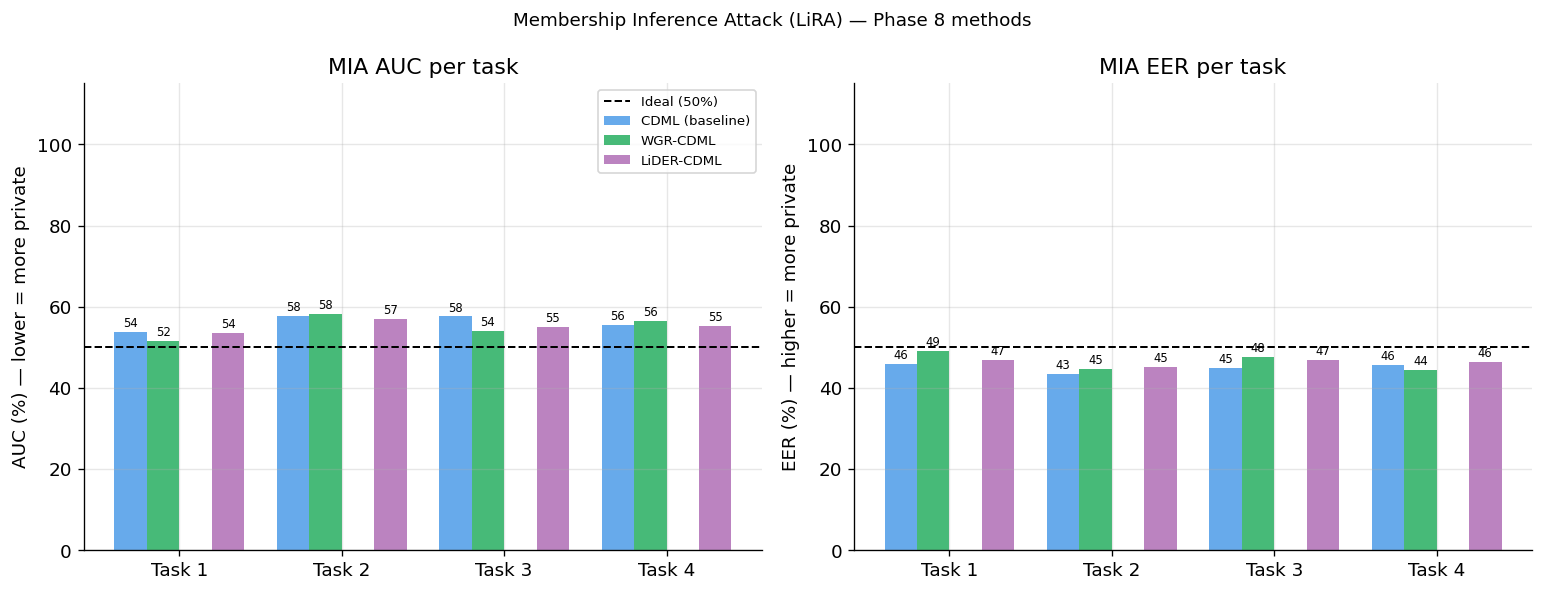

In [64]:
print('Running LiRA MIA on all methods...')
mia_results = {}
for label, _, _, model in all_runs:
    if label == 'CaSpeR-CDML':
        print(f'  Skipping MIA for {label} (incompatible with CDML scrambling)')
        continue
    per_task_auc, per_task_eer = [], []
    for t in task_names:
        m_s  = get_logit_scores(model, task_data[t]['train'], DEVICE, cdml_task=t)
        nm_s = get_logit_scores(model, task_data[t]['test'],  DEVICE, cdml_task=t)
        a, e, _, _ = compute_mia_auc_eer(m_s, nm_s)
        per_task_auc.append(a)
        per_task_eer.append(e)
    mia_results[label] = {'auc': per_task_auc, 'eer': per_task_eer}
    print(f'  {label}: mean AUC={np.mean(per_task_auc):.1f}%  '
          f'mean EER={np.mean(per_task_eer):.1f}%')

# ── MIA bar chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(n_tasks)
w = 0.20
offsets = np.linspace(-1.5*w, 1.5*w, len(all_runs))

for ax_i, metric in enumerate(['auc', 'eer']):
    ax = axes[ax_i]
    for i, (label, _, color, _) in enumerate(all_runs):
        if label == 'CaSpeR-CDML':
            continue  # skip AUC for CaSpeR-CDML (incompatible with CDML)
        vals = mia_results[label][metric]
        bars = ax.bar(x + offsets[i], vals, w, label=label,
                      color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.5,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7)
    ax.axhline(50, color='black', linestyle='--', lw=1.2,
               label='Ideal (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(task_names)
    ax.set_ylim(0, 115)
    ylabel = 'AUC (%) — lower = more private' if metric == 'auc' \
             else 'EER (%) — higher = more private'
    ax.set_ylabel(ylabel)
    ax.set_title(f'MIA {metric.upper()} per task')
    if ax_i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Membership Inference Attack (LiRA) — Phase 8 methods',
             fontsize=11)
plt.tight_layout()
plt.savefig('../Plots/fig_phase8_mia.png', bbox_inches='tight')
plt.show()

## 7. Latent space analysis — t-SNE comparison

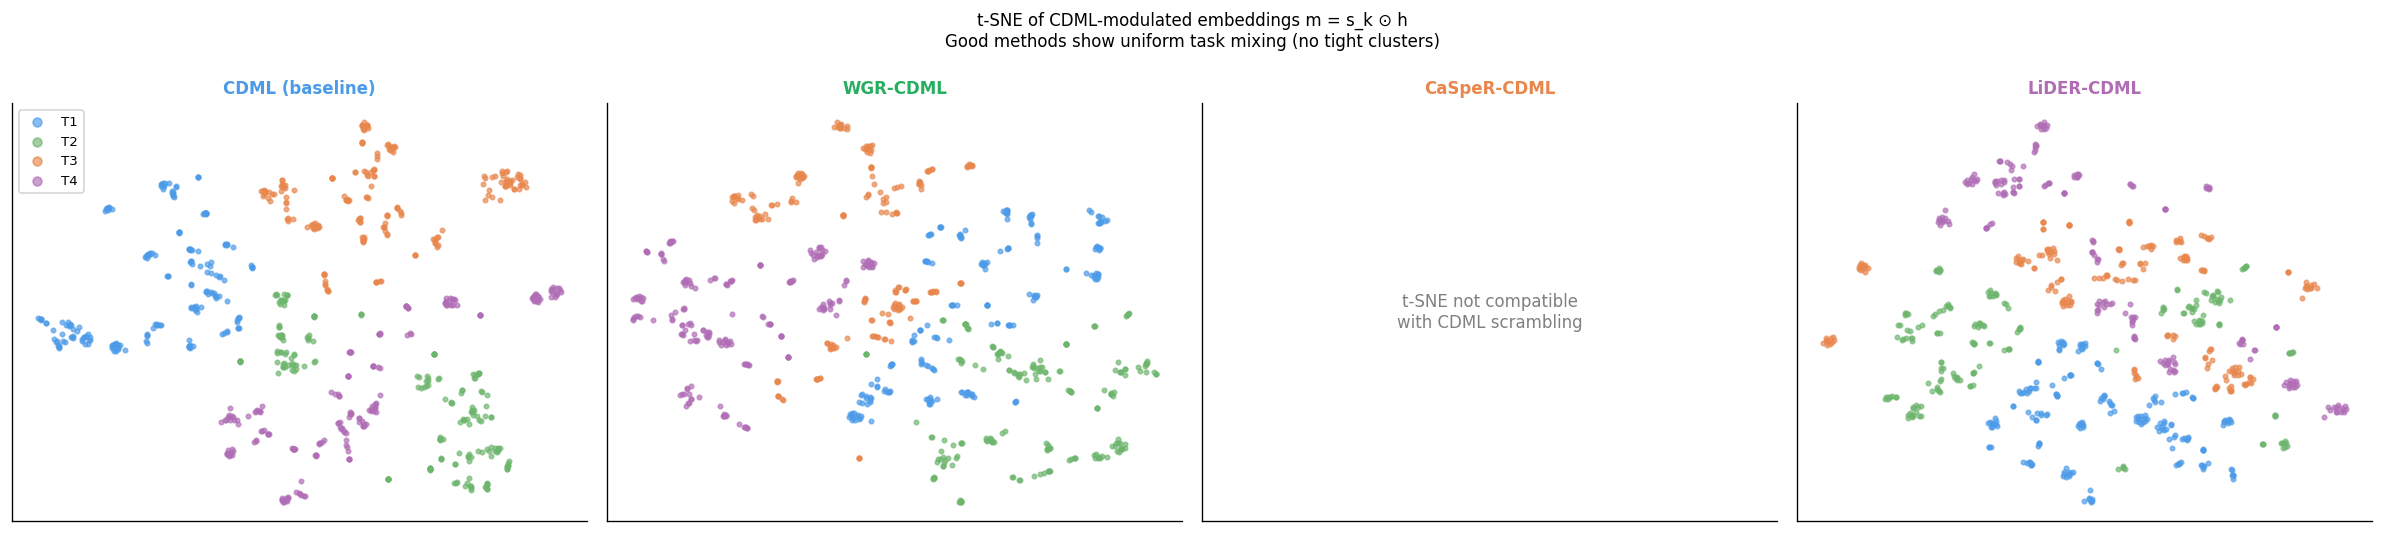

In [66]:
@torch.no_grad()
def extract_embeddings(model, task_data, task_names, device,
                        max_per_task=200, use_scrambled=True):
    """Extract (optionally CDML-scrambled) embeddings for t-SNE."""
    model.eval()
    all_embeds, all_task_labels = [], []

    for t_idx, t_name in enumerate(task_names):
        if hasattr(model, 'set_task_sequence') and t_name in model.seeds:
            model.set_task_sequence(t_name, model.seeds[t_name])

        loader = DataLoader(task_data[t_name]['test'],
                            batch_size=256, shuffle=False)
        embeds = []
        for X_b, _ in loader:
            X_b = X_b.to(device)
            if use_scrambled and hasattr(model, 'embed_modulated'):
                h = model.embed_modulated(X_b)
            elif hasattr(model, 'embed_raw'):
                h = model.embed_raw(X_b)
            elif hasattr(model, 'backbone'):
                h = model.backbone.embed(X_b)
            else:
                h = model.embed(X_b)
            embeds.append(h.cpu().numpy())

        embeds = np.concatenate(embeds)[:max_per_task]
        all_embeds.append(embeds)
        all_task_labels.extend([t_idx] * len(embeds))

    return np.concatenate(all_embeds), np.array(all_task_labels)


task_palette = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']
fig, axes = plt.subplots(1, len(all_runs), figsize=(5 * len(all_runs), 4.5))

for ax, (label, _, color, model) in zip(axes, all_runs):
    if label == 'CaSpeR-CDML':
        ax.text(0.5, 0.5, 't-SNE not compatible\nwith CDML scrambling',
                ha='center', va='center', fontsize=10, color='gray')
        ax.set_title(label, fontsize=10, fontweight='bold', color=color)
        ax.set_xticks([]); ax.set_yticks([])
        continue
    embeds, task_labels = extract_embeddings(
        model, task_data, task_names, DEVICE)
    tsne = TSNE(n_components=2, perplexity=30,
                random_state=RANDOM_SEED, n_iter=400)
    proj = tsne.fit_transform(embeds)
    for t_idx in range(n_tasks):
        mask = (task_labels == t_idx)
        ax.scatter(proj[mask, 0], proj[mask, 1],
                   c=task_palette[t_idx], s=7, alpha=0.65,
                   label=f'T{t_idx+1}')
    ax.set_title(label, fontsize=10, fontweight='bold', color=color)
    ax.set_xticks([]); ax.set_yticks([])

axes[0].legend(fontsize=8, markerscale=2)
plt.suptitle('t-SNE of CDML-modulated embeddings m = s_k ⊙ h\n'
             'Good methods show uniform task mixing (no tight clusters)',
             fontsize=10)
plt.tight_layout()
plt.savefig('../Plots/fig_phase8_tsne.png', bbox_inches='tight')
plt.show()

## 8. Accuracy–Privacy trade-off scatter

  Skipping MIA for CaSpeR-CDML (incompatible with CDML scrambling)


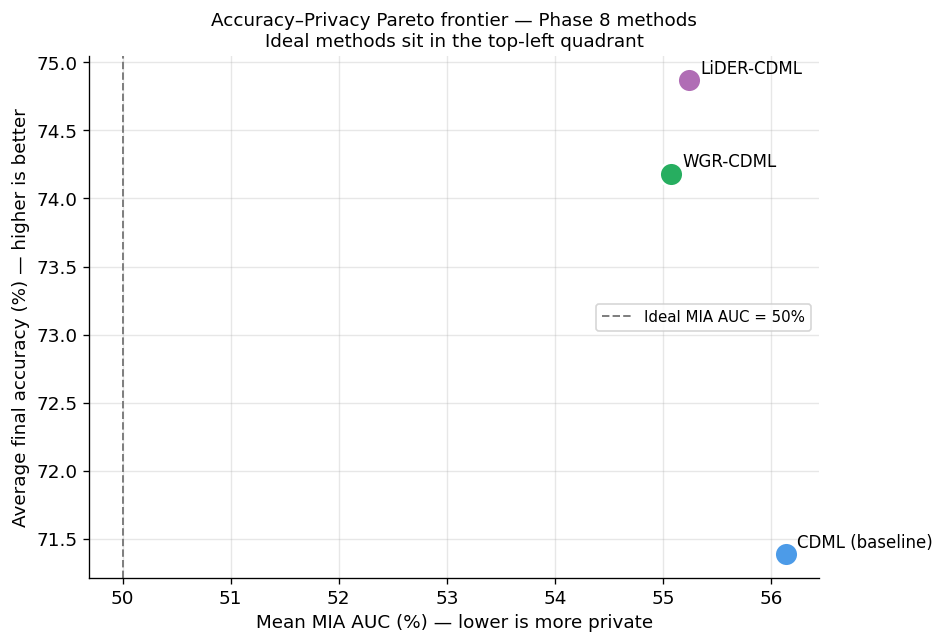

In [68]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for label, mat, color, _ in all_runs:
    avg_acc  = np.nanmean(mat[-1, :]) * 100
    if label == 'CaSpeR-CDML':
        print(f'  Skipping MIA for {label} (incompatible with CDML scrambling)')
        continue
    mean_auc = np.mean(mia_results[label]['auc'])
    ax.scatter(mean_auc, avg_acc, s=200, color=color, zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.annotate(label, (mean_auc, avg_acc),
                textcoords='offset points', xytext=(7, 4), fontsize=10)

ax.axvline(50, color='grey', linestyle='--', lw=1.2,
           label='Ideal MIA AUC = 50%')
ax.set_xlabel('Mean MIA AUC (%) — lower is more private', fontsize=11)
ax.set_ylabel('Average final accuracy (%) — higher is better', fontsize=11)
ax.set_title('Accuracy–Privacy Pareto frontier — Phase 8 methods\n'
             'Ideal methods sit in the top-left quadrant', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../Plots/fig_phase8_tradeoff.png', bbox_inches='tight')
plt.show()

## 10. LiDER ablation — spectral norm evolution

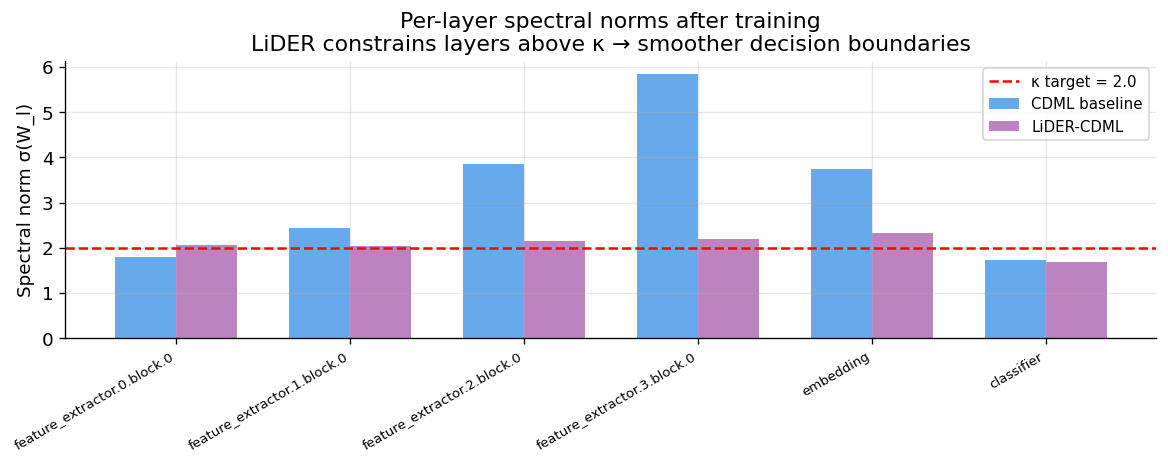

Layer spectral norms comparison:
  Layer                              CDML     LiDER         Δ
  -------------------------------------------------------
  feature_extractor.0.block.0       1.801     2.057    +0.256
  feature_extractor.1.block.0       2.434     2.035    -0.399
  feature_extractor.2.block.0       3.842     2.147    -1.695
  feature_extractor.3.block.0       5.842     2.194    -3.648
  embedding                         3.747     2.327    -1.421
  classifier                        1.725     1.692    -0.034


In [69]:
# Visualise how LiDER constrains per-layer spectral norms over training steps
# Compare CDML baseline vs LiDER-CDML

@torch.no_grad()
def get_spectral_norms(model):
    norms = []
    backbone = model.backbone if hasattr(model, 'backbone') else model
    for name, module in backbone.named_modules():
        if isinstance(module, (nn.Conv1d, nn.Linear)):
            W     = module.weight
            sigma = spectral_norm_approx(W).item()
            norms.append((name, sigma))
    return norms


norms_cdml  = get_spectral_norms(model_cdml)
norms_lider = get_spectral_norms(model_lider)

layer_names  = [n for n, _ in norms_cdml]
vals_cdml    = [v for _, v in norms_cdml]
vals_lider   = [v for _, v in norms_lider]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(layer_names))
w = 0.35
ax.bar(x - w/2, vals_cdml,  w, label='CDML baseline', color='#4C9BE8', alpha=0.85)
ax.bar(x + w/2, vals_lider, w, label='LiDER-CDML',    color='#B06DB5', alpha=0.85)
ax.axhline(LIDER_KAPPA, color='red', linestyle='--', lw=1.5,
           label=f'κ target = {LIDER_KAPPA}')
ax.set_xticks(x)
ax.set_xticklabels(layer_names, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Spectral norm σ(W_l)')
ax.set_title('Per-layer spectral norms after training\n'
             'LiDER constrains layers above κ → smoother decision boundaries')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../Plots/fig_phase8_spectral_norms.png', bbox_inches='tight')
plt.show()

print('Layer spectral norms comparison:')
print(f'  {"Layer":<30} {"CDML":>8}  {"LiDER":>8}  {"Δ":>8}')
print('  ' + '-' * 55)
for name, vc, vl in zip(layer_names, vals_cdml, vals_lider):
    print(f'  {name:<30} {vc:>8.3f}  {vl:>8.3f}  {vl-vc:>+8.3f}')

## 11. Complete results summary

In [71]:
print('=' * 70)
print('PHASE 8 RESULTS SUMMARY')
print('=' * 70)

print(f'\n{"Method":<22} {"AvgAcc":>8} {"T1 drop":>9} '
      f'{"MIA AUC":>9} {"MIA EER":>9} {"Overhead"}')
print('-' * 70)

overhead = {
    'CDML (baseline)': '4 B/task',
    'WGR-CDML':        '4 B/task + DWT stats (no raw)',
    'CaSpeR-CDML':     '4 B/task + 10% raw replay',
    'LiDER-CDML':      '4 B/task + 10% raw replay',
}

for label, mat, _, _ in all_runs:
    avg_acc  = np.nanmean(mat[-1, :]) * 100
    t1_drop  = (mat[0, 0] - mat[-1, 0]) * 100
    if label == 'CaSpeR-CDML':
        print(f'  {label:<20} {avg_acc:>8.1f} {t1_drop:>9.1f} '
              f'{"N/A":>9} {"N/A":>9}  {overhead[label]}')
        continue
    mean_auc = np.mean(mia_results[label]['auc'])
    mean_eer = np.mean(mia_results[label]['eer'])
    print(f'  {label:<20} {avg_acc:>8.1f} {t1_drop:>9.1f} '
          f'{mean_auc:>9.1f} {mean_eer:>9.1f}  {overhead[label]}')

print('\n  Ideal: high AvgAcc, low T1 drop, MIA AUC ≈ 50%, MIA EER ≈ 50%')
print('=' * 70)

PHASE 8 RESULTS SUMMARY

Method                   AvgAcc   T1 drop   MIA AUC   MIA EER Overhead
----------------------------------------------------------------------
  CDML (baseline)          71.4      45.8      56.1      45.0  4 B/task
  WGR-CDML                 74.2      38.4      55.1      46.5  4 B/task + DWT stats (no raw)
  CaSpeR-CDML              59.4      47.4       N/A       N/A  4 B/task + 10% raw replay
  LiDER-CDML               74.9      45.6      55.2      46.3  4 B/task + 10% raw replay

  Ideal: high AvgAcc, low T1 drop, MIA AUC ≈ 50%, MIA EER ≈ 50%


## 12. Discussion

### Method A — WGR-CDML

**What to look for:** WGR-CDML should outperform the CDML baseline in terms of
average accuracy and Task 1 forgetting, because synthetic replay enriches the
training signal at each step. The key trade-off to examine is whether the synthetic
samples are diverse enough (jitter, stochastic coefficient sampling) to prevent
the model from treating them as a trivially-recognisable synthetic distribution.

**Privacy advantage over standard replay:** Standard 10% replay stores ~60 real
biometric windows per task. WGR-CDML stores only the per-class mean and covariance
of 16 wavelet coefficients (approx. 30 × 32 = 960 floats per task), which cannot
be inverted to recover any individual's gait pattern. The MIA AUC should remain
near 50% because the CDML scrambling is still applied to synthetic samples.

**Wavelet choice (db4):** Daubechies-4 is widely used for biological signals.
The 3-level decomposition of a 128-sample window gives approximation coefficients
of length 16, capturing the ~0–4 Hz gait cycle. Higher levels (4–5) can be
explored as an ablation.

### Method B — CaSpeR-CDML

**What to look for:** The t-SNE visualisation is the most direct indicator.
Without CaSpeR, replay buffer classes from different tasks increasingly mix in the
scrambled embedding space. With CaSpeR, the regulariser should enforce tighter
intra-class clustering and larger inter-class gaps — visible as more distinct
colour regions in the t-SNE plot.

**Important nuance:** CaSpeR operates on the *scrambled* embeddings m = s_k ⊙ h.
Since different tasks use different binary sequences, the geometric structure of
embeddings from different tasks is already disrupted by CDML. The CaSpeR loss
should primarily benefit *within-task* class separation rather than cross-task
separation. This is actually desirable: it improves the classifier's discriminability
among the 30 subjects within a task without creating a cross-task geometric structure
that could be exploited by an IIA attacker.

**λ ablation:** The λ sweep (Section 9) reveals the regularisation strength
needed for this 1-D IMU setting. Since the embedding dimension (128) matches
the LGG node count, the Laplacian eigenvalue computation is efficient.
Too high a λ may over-regularise and prevent the model from fitting the
current task's new subjects.

### Method C — LiDER-CDML

**What to look for:** The spectral norm plot (Section 10) directly shows whether
LiDER successfully constrains the network's Lipschitz constants. Layers with
σ(W) >> κ in the baseline should have σ ≤ κ in the LiDER model. The improvement
in generalisation accuracy should be visible in the off-diagonal accuracy matrix
cells (forgetting on Tasks 1–3 when evaluated after Task 4).

**Buffer overfitting diagnosis:** To confirm that LiDER addresses buffer
overfitting specifically, compare the accuracy on *buffer samples* vs *unseen
test samples* of the same class. Buffer accuracy should be similar in both
methods (high), but test accuracy should be higher in LiDER-CDML.

### Synthesis for thesis

The three methods address three distinct failure modes of plain CDML:
- **Insufficient replay diversity** → WGR-CDML (frequency-domain synthesis)
- **Latent space geometry degradation** → CaSpeR-CDML (spectral partitioning)
- **Buffer overfitting** → LiDER-CDML (Lipschitz smoothing)

A natural next step is to combine all three into a unified system:
WGR provides diverse synthetic replay; CaSpeR regularises the geometry
of those replayed embeddings; LiDER prevents overfitting to the buffer.
This combination would constitute a strong novel contribution.

---
*Notebook: phase8_advanced_methods.ipynb*